# Feature Engineering (Создание новых признаков)

In [1]:
%pip install plotly
%matplotlib inline
from setup_libs import *
import numpy as np
import seaborn as sns
from sklearn import metrics
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Feature Engineering в классификации

Под этим словосочетанием подразумевают создание и подготовку признаков объектов, чтобы они лучше подходили под алгоритмы и давали наилучший результат. Рассмотрим пример концентрических окружностей.

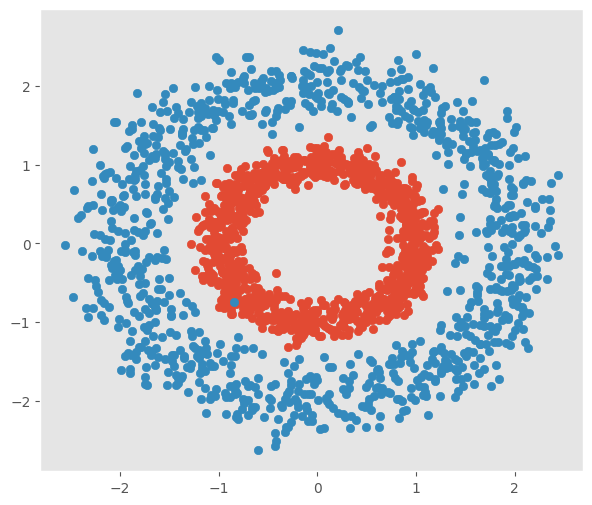

In [2]:
num_samples = 1000
theta = np.linspace(0, 2*np.pi, num_samples)

r1 = 1
r2 = 2

rng = np.random.RandomState(1)

circle = np.hstack([np.cos(theta).reshape((-1, 1)) + (rng.randn(num_samples)[:,np.newaxis] / 8),
                    np.sin(theta).reshape((-1, 1)) + (rng.randn(num_samples)[:,np.newaxis] / 8)])
lil = r1 * circle
big = r2 * circle
X = np.vstack([lil, big])
y = np.hstack([np.zeros(num_samples), np.ones(num_samples)])

# plots
plt.figure(figsize=(7,6))
plt.scatter(lil[:,0],lil[:,1])
plt.scatter(big[:,0],big[:,1])
plt.grid()

<div style='background-color: #ffeb3b; padding: 15px; border-left: 5px solid #ffc107; margin: 10px 0'>
<b>Вопрос:</b> Что сложного в задаче классификации таких данных? 
</div>



Мы уже знаем несколько алгоритмов классификации - `knn` и `Naive Bayes` и знаем один из алгоритмов регрессии `linear regression`. Совсем скоро мы познакомимся подробно с ещё одним алгоритмом классификации - `logistic regression`, но сегодня его устройство будет рассмотрено лишь поверхностно.

Вспомним, что такое `linear regression`:

Уравнение линейной регрессии задает линейную зависимость между входными признаками $x$ и выходным значением $y$:

$$\hat{y} = a(x, w) = w_0 + w_1 x_1 + w_2 x_2 + \dots + w_n x_n$$

Для удобства записи, особенно при работе с матрицами, свободный член $w_0$ часто включают в вектор весов. Для этого к вектору признаков добавляется фиктивный признак, всегда равный 1. В результате получаем:

$$x = (1, x_1, x_2, \dots, x_n)^T, \quad w = (w_0, w_1, w_2, \dots, w_n)^T$$

И уравнение принимает компактный векторный вид:

$$\hat{y} = w^T x = <w, x>$$

А что если мы теперь будем проводить $n$-мерную разделяющую гиперплоскость и рассуждать так:
* Всё что выше этой гиперплоскости, то относится к классу №1
* Всё остальное к классу №2

Звучит логично и довольно просто. Осталось только применить некоторое нелинейное преобразование к результату $\hat{y} = <w, x>$, которое бы переводило его в пространство $[0, 1]$, чтобы мы могли смотреть на задачу классификации с вероятностной точки зрения.

Итого, пока что, уравнение `логистической регрессии` записывается вот так:

$$\hat{y} = \sigma(<w, x>)$$

Более подробно про сам алгоритм, про классификацию и про $\sigma$ вы узнаете на будущей лекции! Хотя вы уже работали с `logistic regression` на прошлой практике :)

Пока что будем смотреть на задачу бинарной классификации при помощи линейных моделей вот с такой точки зрения:

![alttext](../data/class.webp)

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Масштабирование признаков (важно для KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Создание и обучение модели
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


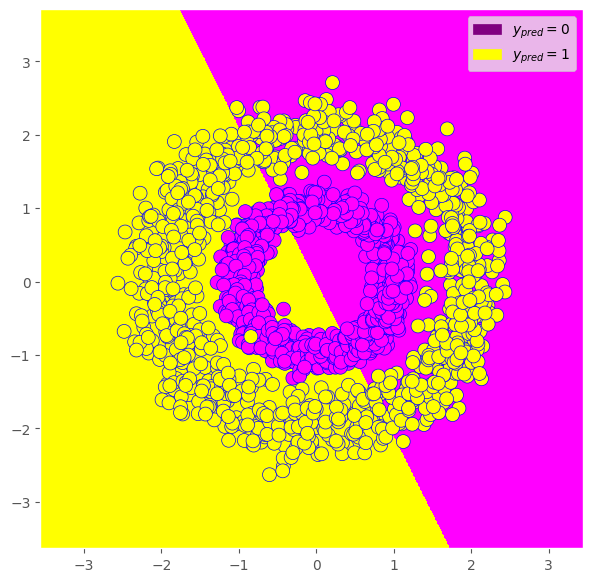

In [4]:
plot_model(X, y, lr)

Получилось не очень, ну оно и верно! Как мы собирались линейно неразедлимую выборку разделить линейно???

![alttext](../data/tort.jpg)

Вспомним старую добрую задачку про то, как поделить торт за **минимальное** количество разрезов на 8 равных частей, а заодно можно вспомнить и основную формулу информатики (формулу Хартли $2^i = N$)

Очевидно, что торт линейно не разделим на 8 равных частей за 3 разреза, однако, кто нам запрещает перейти из двухмерного пространства в трёхмерное. И третий разрез сделать вдоль?

Давайте попробуем добавить какой-то новый признак, какие-то новые знания, какую-то новую информацию про наши объекты. Давайте добавим радиус `r` в наши данные, т.е. добавим новый признак

In [5]:
scaler_new = StandardScaler()
r = X[:,0]**2 + X[:,1]**2  # Новый признак

X_new = np.hstack([X, r.reshape([-1,1])]) # Добавляем его в нашу матрицу: объекты-признаки

X_new_train, X_new_test, y_train, y_test = train_test_split(X_new, y, test_size=0.3, random_state=42, stratify=y)

X_new_train_scaled = scaler_new.fit_transform(X_new_train)
X_new_test_scaled = scaler_new.transform(X_new_test)

lr_new = LogisticRegression()
lr_new.fit(X_new_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


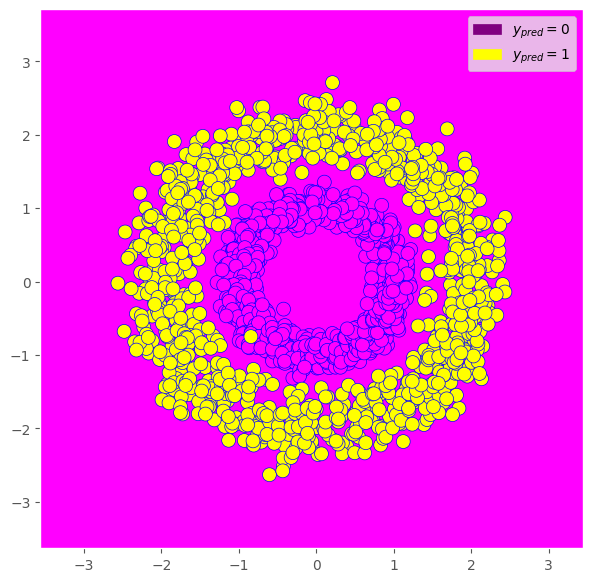

In [6]:
plot_model(X_new, y, lr_new, produce_data_point= lambda x, y: (x, y, x**2+y**2))

Получилось небольшое `ВАУ`.. Хорошо, давайте подумаем, как мы можем это объяснить?

<div style='background-color: #ffeb3b; padding: 15px; border-left: 5px solid #ffc107; margin: 10px 0'>
<b>Вопрос:</b> Как можно объяснить такое изменение в результате работы модели? 
</div>

Сейчас данные выглядят как два концентрических круга:

В этой плоскости `невозможно` провести линейную гиперповерхность, которая разделит точки на два класса. Любая прямая либо пересечет оба кольца, либо пройдет мимо.


А вот добавление признака $r = x² + y²$ — это способ поднять данные в третье измерение!



In [7]:
# График в 3D можно вращать!
plot_radial_3d_decision_boundary(lr_new, X_new_test_scaled, y_test)


## Feature Engineering в регрессии

In [8]:
def plot_reg(X, y, clf_dtc, X_test, dim=0):
    clf_dtc.fit(X, y)
    Y_test = clf_dtc.predict(X_test)
    plt.figure(figsize=(8, 6))
    plt.scatter(X[:,dim], y, cmap='bwr', s=50, alpha=1)
    plt.plot(X_test[:,dim], Y_test, color='r', alpha=1)
    plt.grid()

In [9]:
def f(x):
    return np.sqrt(x) + np.sin(x)

vf = np.vectorize(f)
rng = np.random.RandomState(1)

X_reg = np.arange(0, 10, 0.2)[:, np.newaxis]
y_reg = vf(X_reg) + (rng.rand(50)[:,np.newaxis] / 2)#добавляем шумы

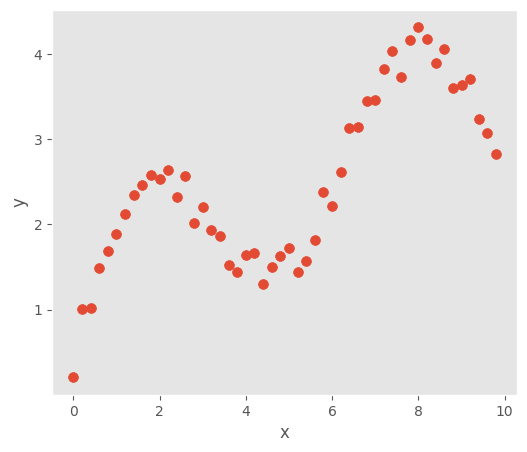

In [10]:
plt.figure(figsize=(6, 5))
plt.scatter(X_reg, y_reg, cmap='bwr', s=50, alpha=1)
plt.xlabel('x')
plt.ylabel('y')
plt.grid()

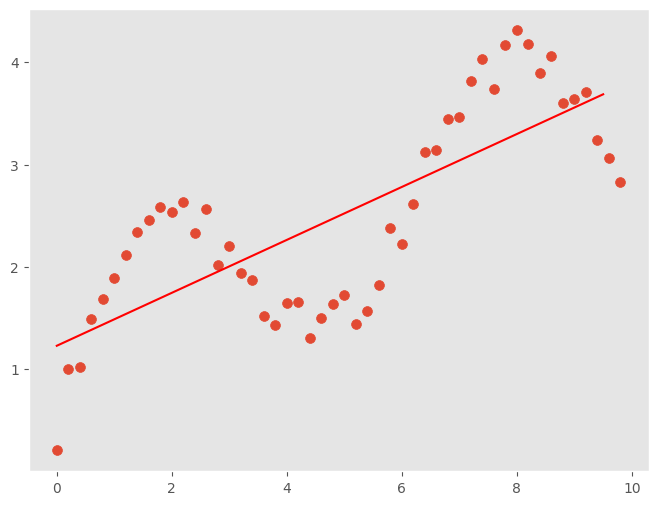

In [11]:
from sklearn.linear_model import LinearRegression as LR
reg_lr = LR()  # No-brain LR
X_test = np.arange(0, 10, 0.5)[:,np.newaxis]
plot_reg(X_reg, y_reg, reg_lr, X_test)

Получилось опять не очень. Что тогда будем делать?

Получилось небольшое `ВАУ`.. Хорошо, давайте подумаем, как мы можем это объяснить?

<div style='background-color: #ffeb3b; padding: 15px; border-left: 5px solid #ffc107; margin: 10px 0'>
<b>Вопрос:</b> Какие есть идеи на этот раз?
</div>

.

.

.

.

.

.

.

.

.

Добавим функции второй, третей и четвертых степеней. Попробуем описать данные полиномом (относительно $x$). Заметим, что относительно $w$ мы всё пользуемся `линейной` моделью

In [12]:
X_reg_new = np.hstack([X_reg, X_reg**2, X_reg**3, X_reg**4])
X_test_new = np.hstack([X_test, X_test**2, X_test**3, X_test**4])

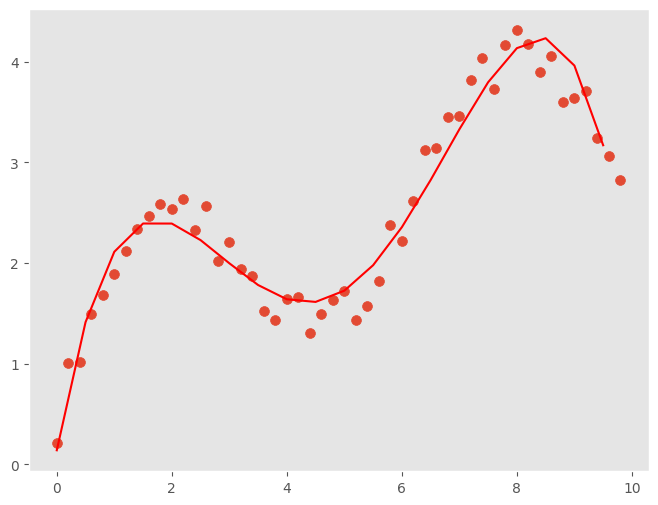

In [13]:
from sklearn.linear_model import LinearRegression as LR
reg_lr = LR()
plot_reg(X_reg_new, y_reg, reg_lr, X_test_new)

В изначальной линейной регрессии мы находимся в пространстве линейных алгоритмов:
$$a(x) = a_0x_0 + a_1x_1 + \ldots a_nx_n$$
    
Но теперь место фич у нас заняли полиномиальные функции и мы получили степенную функцию:

$$a(x) = a_0 + a_1x^1 + \ldots a_nx^n$$

Чтобы не делать это вручную, есть механизм `PolynomialFeatures`

In [14]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=8)

X_reg2 = poly.fit_transform(X_reg)
X_test2 = poly.fit_transform(X_test)

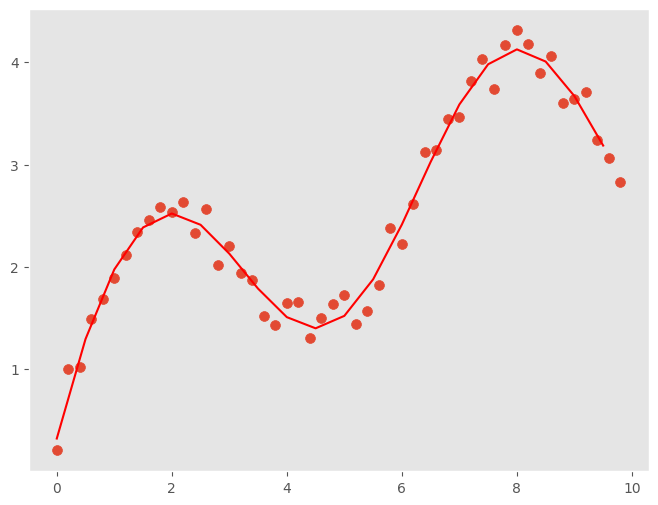

In [15]:
from sklearn.linear_model import LinearRegression as LR
reg_lr = LR()
plot_reg(X_reg2, y_reg, reg_lr, X_test2, dim=1)

С другой стороны мы можем догадаться, что тут не степенные функции и использовать те функции, которые нужны.

In [16]:
X_reg3 = np.hstack([X_reg, X_reg**0.5, np.sin(X_reg)])
X_test3 = np.hstack([X_test, X_test**0.5, np.sin(X_test)])

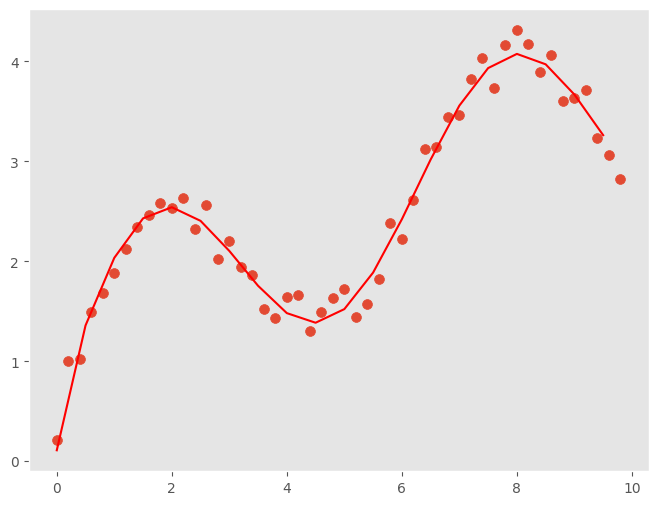

In [17]:
from sklearn.linear_model import LinearRegression as LR
reg_lr = LR()
plot_reg(X_reg3, y_reg, reg_lr, X_test3, dim=0)

`PolynomialFeatures` — это инструмент автоматического `Feature Engineering`. Если в ручном режиме вы сами придумали добавить $x^2+y^2$
, то этот трансформер делает всё за вас: он создает квадраты, кубы и взаимодействия (перемножения) всех имеющихся признаков.


**Простыми словами:** он переводит задачу из 2D в «искривленное» пространство высокой размерности, где линейная модель может провести сложный нелинейный разрез.

### Проклятие размерности

Добавление большого количества новых признаков может повлечь за собой "проклятие размерности"

`Проклятие размерности`»` — это термин, описывающий ряд проблем, которые возникают при работе с данными в пространствах с большим количеством признаков (высокой размерностью).

Если кратко, суть в следующем:
1. Разреженность: С ростом числа признаков объем пространства растет экспоненциально, и имеющиеся данные становятся «редкими». Чтобы сохранить ту же плотность заполнения, нужно гигантское количество новых примеров.
2. Потеря различий: В многомерном пространстве расстояния между объектами выравниваются. Все точки становятся примерно одинаково удаленными друг от друга, из-за чего алгоритмы (например, KNN) перестают эффективно находить сходства.
3. Переобучение: Модели легко находят случайные закономерности в шуме лишних признаков.


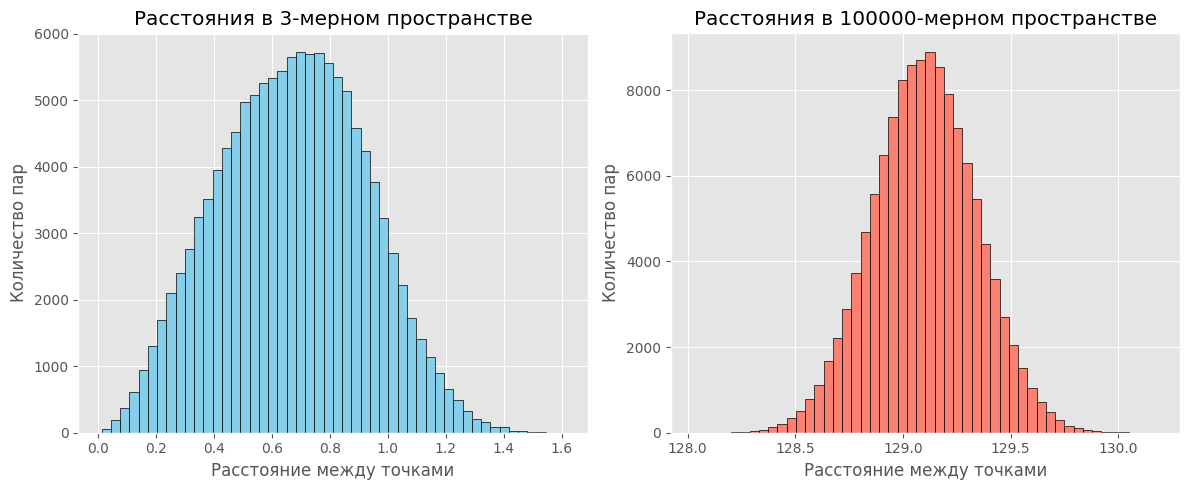

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist

def plot_distances(dims, n_points=500):
    plt.figure(figsize=(12, 5))

    for i, d in enumerate(dims):
        # Генерируем 500 случайных точек в d-мерном пространстве
        data = np.random.rand(n_points, d)
        # Вычисляем попарные расстояния между всеми точками
        distances = pdist(data)

        plt.subplot(1, 2, i+1)
        plt.hist(distances, bins=50, color='skyblue' if d < 10 else 'salmon', edgecolor='black')
        plt.title(f'Расстояния в {d}-мерном пространстве')
        plt.xlabel('Расстояние между точками')
        plt.ylabel('Количество пар')

    plt.tight_layout()
    plt.show()


plot_distances([3, 100000])

1. **В 3D (слева):** Расстояния распределены широко. Есть пары точек, которые очень близки (почти 0), и те, что далеко. Алгоритм легко найдет ближайшего соседа.

2. **В 100000 (справа):** Все расстояния «сбиваются» в узкую кучу. Минимальное расстояние почти не отличается от среднего.


В 1D или 2D мы легко отличаем «близких» соседей от «далеких». Но в **проклятом** пространстве с высокой размерностью (например, 500 или 1000 признаков) все точки становятся почти одинаково удаленными друг от друга, и понятие «сосед» теряет смысл.

## Метрики (база)

**Метрика** — это числовой показатель, который говорит нам, насколько хорошо модель справляется с задачей. Это «линейка», которой мы измеряем качество работы алгоритма на понятном человеку языке.

Метрики бывают разные для разных задач. Обычно метрику выбирают заранее, чтобы понимать, как именно оценивать результат работы модели

Например, в задачах `Computer Vision` используют метрику `IoU` ([Intersection over Union](https://en.wikipedia.org/wiki/Jaccard_index)):

![alttext](../data/IoU.png)

### Метрика - это НЕ Loss (функция потерь)

Хотя оба термина оценивают ошибку, у них разные цели:

* `Loss (Функция потерь):` Используется алгоритмом для обучения. Она должна быть дифференцируемой (математически удобной для оптимизации).

* `Метрика:` Используется человеком для оценки бизнес-результата. Она должна быть интерпретируемой.

### Базовые метрики для Регрессии

Регрессия предсказывает конкретные числа (цену, температуру, рост).
* `MAE (Mean Absolute Error):` Средняя абсолютная ошибка. Показывает, на сколько в среднем (в тех же единицах) ошибается модель.
* `MSE (Mean Squared Error):` Среднеквадратичная ошибка. Сильнее штрафует модель за большие промахи.
* `R² (Коэффициент детерминации):` Доля объясненной дисперсии. 1 — идеальное предсказание, 0 — модель на уровне среднего значения.

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Пример данных
y_true = [100, 200, 300, 400]
y_pred = [110, 190, 280, 450]

print(f"MAE: {mean_absolute_error(y_true, y_pred)}")
print(f"MSE: {mean_squared_error(y_true, y_pred)}")
print(f"R2 Score: {r2_score(y_true, y_pred):.2f}")

MAE: 22.5
MSE: 775.0
R2 Score: 0.94


### Базовые метрики для Классификации

Классификация предсказывает категорию (да/нет, спам/не спам).
* `Accuracy (Точность):` Процент правильных ответов. Плохо работает, если классы несбалансированы (например, в данных 99% здоровых и 1% больных).
* `Confusion Matrix (Матрица ошибок):` Таблица, которая показывает, где именно модель ошиблась: приняла ли она «кошку» за «собаку» или наоборот.

Accuracy: 75.0%


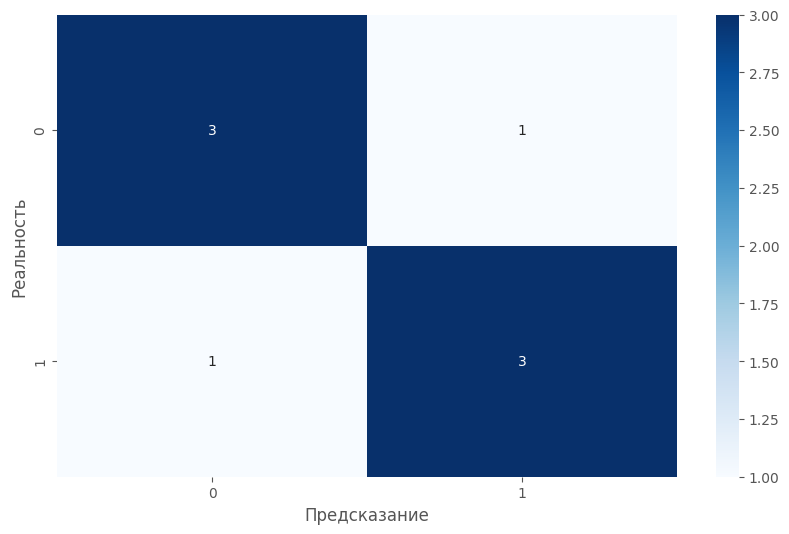

In [22]:
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Пример данных (0 - нет, 1 - да)
y_true = [0, 1, 0, 0, 1, 1, 0, 1]
y_pred = [0, 1, 1, 0, 1, 0, 0, 1]

print(f"Accuracy: {accuracy_score(y_true, y_pred) * 100}%")

# Визуализация Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предсказание')
plt.ylabel('Реальность')
plt.show()

На следующей паре ты узнаешь про более продвинутые метрики для классификации.

## Небольшая практика

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Загрузка данных
df = sns.load_dataset('titanic')

# --- ЭТАП 1: Feature Engineering ---
# TODO: Заполните пропуски в 'age' медианой
# df['age'] = ...


# TODO: Создайте FamilySize и IsAlone
# df['FamilySize'] = ...
# df['IsAlone'] = ...

# TODO: Сделайте биннинг для возраста (bins=[0, 12, 18, 60, 120])
# df['AgeGroup'] = ...

# TODO: Примените логарифмирование к 'fare' через np.log1p
# df['Fare_Log'] = ...

# --- ЭТАП 2: Кодирование и очистка ---
# TODO: Выберите признаки для модели и примените pd.get_dummies
# Подсказка: используйте drop_first=True для линейных моделей
# df_final = ...

# --- ЭТАП 3: Обучение ---
# TODO: Разделите на X и y, затем на train/test (70/30)
# TODO: Отмасштабируйте признаки через StandardScaler
# TODO: Обучите LogisticRegression

# --- ЭТАП 4: Метрики ---
# TODO: Выведите Accuracy и Confusion Matrix

# Этап 1: Очистка и Feature Engineering
1. **Заполнение пропусков**: Заполни пропуски в `age` медианой.
2. **Социальные связи**: Создай `FamilySize` (`sibsp` + `parch` + 1) и бинарный признак `IsAlone` (1 — если `FamilySize == 1`, иначе 0).
3. **Дискретизация (Binning)**: Разбей `age` на 4 группы через `pd.cut(..., bins=bins, labels=labels))`:
   - Child (0-12), Teen (12-18), Adult (18-60), Senior (60-120). Создай на основе этого колонку `AgeGroup`
4. **Логарифмирование**: Посмотри, как выглядит `fare`. Примени `np.log1p()` к колонке `fare`.

```
Для модели эти 500$ выглядят как гигантский выброс. Логарифм «сжимает» большие значения сильнее, чем маленькие. В итоге распределение из «горба с длиннющим хвостом» превращается в более-менее симметричное «облако», с которым линейным моделям (как логистическая регрессия) работать гораздо легче.
```

# Этап 2: Подготовка к обучению
1. **Baseline**: Обучи «глупую» модель только на признаках `pclass`, `age`, `fare` (заполнив в них пропуски). Запомни её accuracy.
2. **Кодирование**: Примени `pd.get_dummies(drop_first=True)` к признакам `sex`, `embarked`, `AgeGroup`, `who`.
3. **Очистка**: Удали колонки-исходники: `age`, `fare`, `deck`, `embark_town`, `alive`, `class`.
4. **Разделение**: Выдели `X` и `y` (`survived`). Разбей на train/test (70/30, `random_state=42`).

# Этап 3: Обучение
1. **Масштабирование**: Примени `StandardScaler`. Важно: `.fit()` только на train, `.transform()` на train и test.
2. **Моделирование**: Обучи `LogisticRegression`.

# Этап 4: Анализ метрик
1. **Сравнение**: Выведи `accuracy_score`. Стала ли модель лучше после твоего Feature Engineering по сравнению с Baseline?
2. **Матрица ошибок**: Построй `confusion_matrix` через `sns.heatmap`. Ответь на вопрос: кого модель чаще предсказывает неверно — выживших или погибших?

In [20]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


<Axes: >

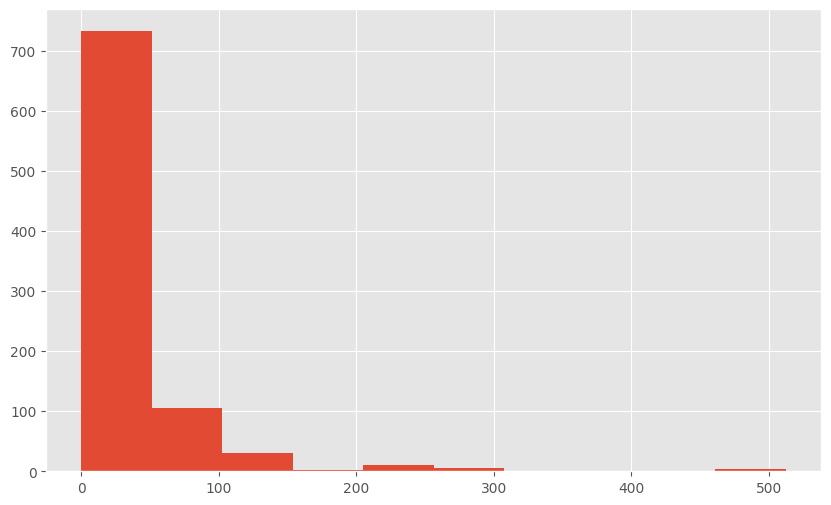

In [22]:
df['fare'].hist()